AttributeError: Quiver.set() got an unexpected keyword argument 'help'

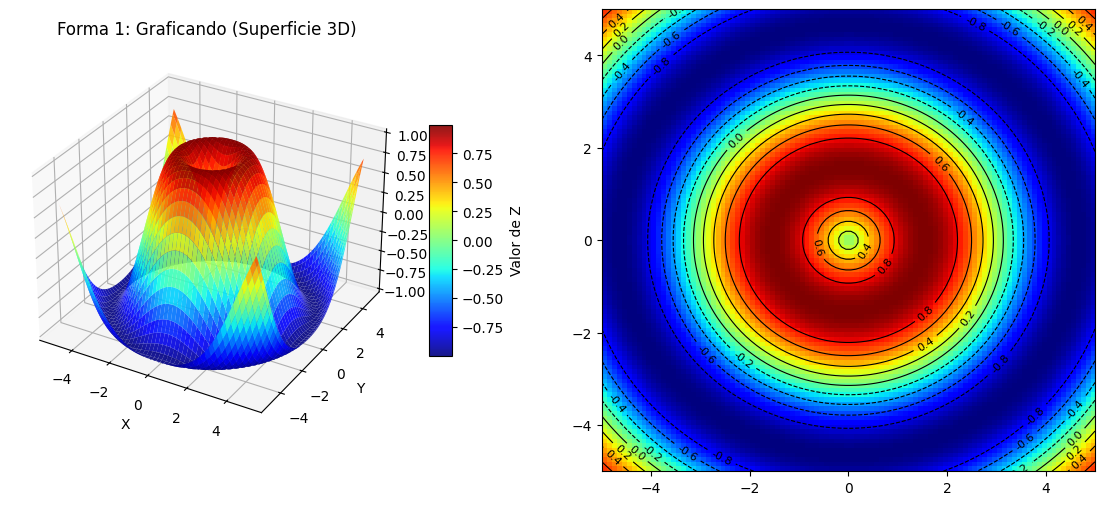

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Definir la función matemática (un "sombrero" o montaña)
def f(x, y):
    return np.sin(np.sqrt(x**2 + y**2))

# 2. Crear la malla de puntos (X, Y)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 3. Configurar la figura con dos subgráficas (3D y 2D)
fig = plt.figure(figsize=(14, 6))

# --- PANEL IZQUIERDO: Gráfica de Superficie 3D ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='jet', edgecolor='none', alpha=0.9)
ax1.set_title('Forma 1: Graficando (Superficie 3D)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Valor de Z')

# --- PANEL DERECHO: Mapa de Calor 2D con Curvas de Nivel ---
ax2 = fig.add_subplot(1, 2, 2)
# El mapa de calor de fondo
im = ax2.imshow(Z, extent=[-5, 5, -5, 5], origin='lower', cmap='jet', aspect='auto')
# Las líneas o curvas de nivel encima
lineas_nivel = ax2.contour(X, Y, Z, levels=10, colors='black', linewidths=0.8)
ax2.clabel(lineas_nivel, inline=True, fontsize=8, fmt='%.1f')

# Opcional: Dibujar algunos vectores gradiente (perpendiculares a las curvas)
x_grad = np.linspace(-4, 4, 7)
y_grad = np.linspace(-4, 4, 7)
X_g, Y_g = np.meshgrid(x_grad, y_grad)
# Derivadas parciales numéricas para el gradiente
dZ_dy, dZ_dx = np.gradient(f(X_g, Y_g))
ax2.quiver(X_g, Y_g, dZ_dx, dZ_dy, color='white', scale=15, pivot='mid', alpha=0.7,
           help="Vectores perpendiculares que apuntan hacia el rojo")

ax2.set_title('Forma 2: Coloreando (Mapa de calor + Curvas de nivel)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
fig.colorbar(im, ax=ax2, shrink=0.8, label='Valor de Z')

plt.tight_layout()
plt.show()


### Interactive Plot using Plotly

Below are the interactive versions of the 3D surface plot and the 2D heatmap with contour lines, generated using Plotly.

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Re-using the function and meshgrid from the previous cell
# 1. Definir la función matemática (un "sombrero" o montaña)
def f(x, y):
    return np.sin(np.sqrt(x**2 + y**2))

# 2. Crear la malla de puntos (X, Y)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Create subplots: one 3D and one 2D
fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type': 'surface'}, {'type': 'xy'}]],
                    subplot_titles=('Forma 1: Graficando (Superficie 3D)', 'Forma 2: Coloreando (Mapa de calor + Curvas de nivel)'))

# --- LEFT PANEL: 3D Surface Plot ---
fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Jet', showscale=True, colorbar_title='Valor de Z'), row=1, col=1)

fig.update_layout(scene = dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                    scene_camera_eye=dict(x=1.8, y=1.8, z=0.8),
                    margin=dict(l=0, r=0, b=0, t=50)
                  )

# --- RIGHT PANEL: 2D Heatmap with Contour Lines ---
# Add Heatmap
fig.add_trace(go.Heatmap(z=Z, x=x, y=y, colorscale='Jet', showscale=False),
              row=1, col=2)

# Add Contour lines (optional, but good for clarity)
fig.add_trace(go.Contour(z=Z, x=x, y=y, colorscale='Jet',
                         contours_coloring='lines', line_width=2,
                         showlabels=True,  # show labels on contours
                         line_color='black',
                         contours_start=-1,
                         contours_end=1,
                         contours_size=0.2),
              row=1, col=2)

fig.update_xaxes(title_text='X', row=1, col=2)
fig.update_yaxes(title_text='Y', row=1, col=2)

fig.update_layout(height=600, width=1200)

fig.show()

NameError: name 'np' is not defined